## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Accessing and viewing the Data

In [ ]:
df = pd.read_csv("../chicago_crime_dataset.csv")
print(df.columns) # getting the column names of the dataset
print(df.shape) # getting the shape of the dataset


In [ ]:
df.describe()


In [ ]:
df.info()

### Checking for NA values and crime stats

In [ ]:
df.isna().sum()  

In [ ]:
df['Arrest'].value_counts()

In [ ]:
null_category = df.loc[df['X Coordinate'].isna(), 'Primary Type'].value_counts()

null_category.plot(kind='bar', figsize=(10, 5))

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['timestamp'] = df['Date'].dt.strftime('%H:%M')
time_counts = df['timestamp'].value_counts().sort_values(ascending=False).head(10)

In [ ]:
time_counts.plot(kind='line', figsize=(10, 5))

## Reducing and removing rows with null or 00:00:00

In [53]:
df = df.dropna()
df = df[df['timestamp'] != '00:00']

In [55]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year,timestamp
0,13733090,JJ130321,2025-01-28 15:30:00,076XX S RACINE AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,08A,1169643.0,1854247.0,2025,05/17/2025 03:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)",2025,15:30
1,13909076,JJ344224,2025-07-22 12:40:00,011XX W THORNDALE AVE,0560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,...,08A,1167566.0,1939682.0,2025,03/14/2026 03:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)",2025,12:40
2,13101860,JG295014,2023-06-09 20:23:00,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,...,16,1146144.0,1895827.0,2023,08/19/2023 03:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)",2023,20:23
3,13701134,JH553823,2024-12-24 05:38:00,043XX N KIMBALL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,...,07,1152935.0,1928827.0,2024,11/02/2025 03:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)",2024,05:38
4,13967696,JJ415709,2025-09-15 15:20:00,004XX S WESTERN AVE,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,...,03,1160478.0,1897788.0,2025,03/14/2026 03:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)",2025,15:20


In [56]:
df = df.drop(columns=['IUCR','Description','FBI Code','Updated On','Latitude','Longitude','X Coordinate','Y Coordinate','Location','Case Number','_year'])

## Data Distribution Analysis

<Axes: xlabel='District'>

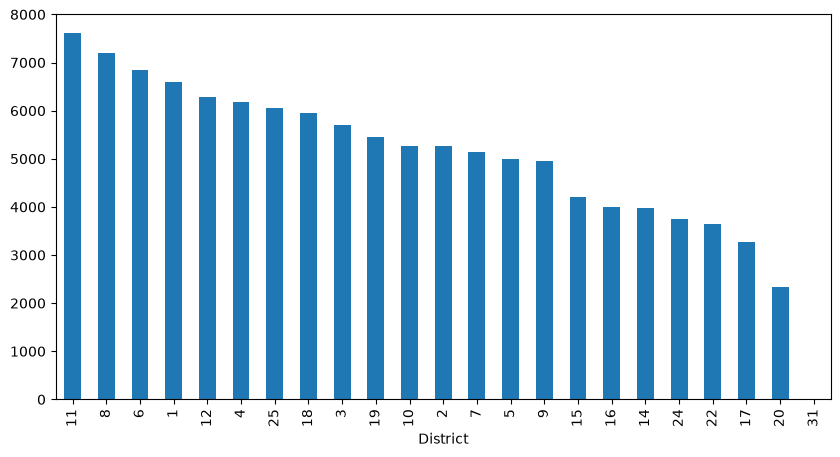

In [62]:
df['District'].value_counts().plot(kind='bar', figsize=(10, 5))

<Axes: xlabel='Primary Type'>

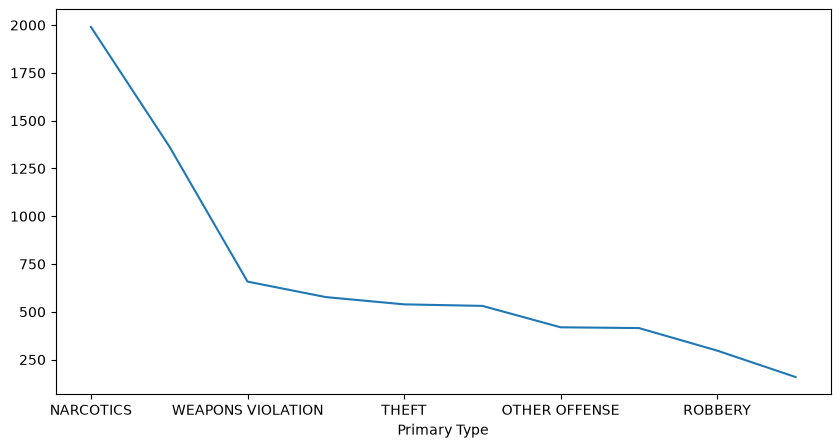

In [64]:
df.loc[df['District'] == 11, 'Primary Type'].value_counts().head(10).plot(kind='line', figsize=(10, 5))

<Axes: xlabel='Primary Type'>

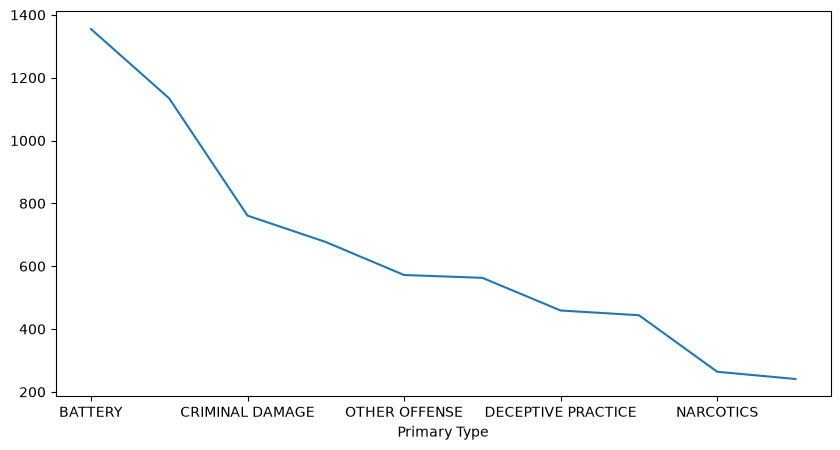

In [65]:
df.loc[df['District'] == 8, 'Primary Type'].value_counts().head(10).plot(kind='line', figsize=(10, 5))

<Axes: xlabel='Primary Type'>

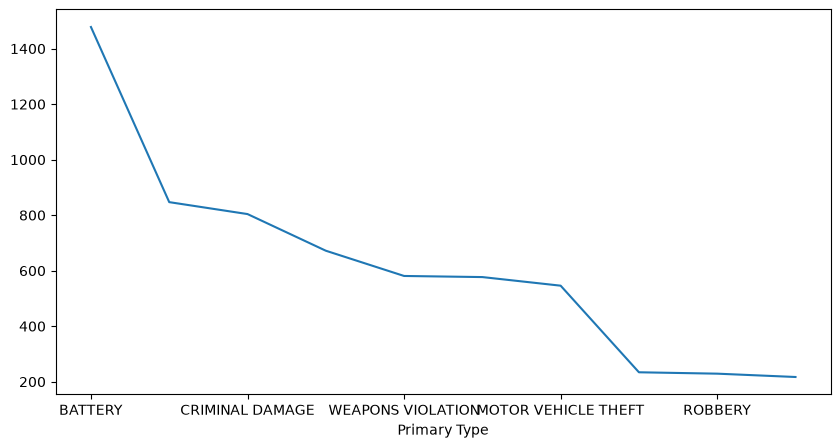

In [66]:
df.loc[df['District'] == 6, 'Primary Type'].value_counts().head(10).plot(kind='line', figsize=(10, 5))

<Axes: xlabel='Primary Type'>

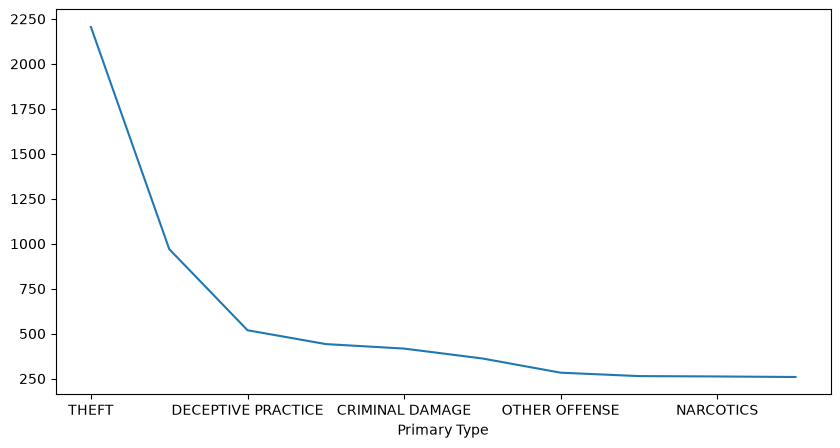

In [67]:
df.loc[df['District'] == 1, 'Primary Type'].value_counts().head(10).plot(kind='line', figsize=(10, 5))

<Axes: xlabel='Primary Type'>

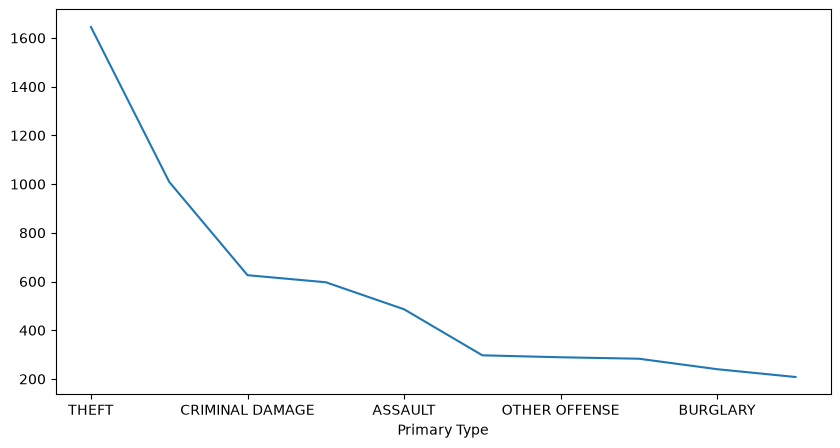

In [68]:
df.loc[df['District'] == 12, 'Primary Type'].value_counts().head(10).plot(kind='line', figsize=(10, 5))

## Top crime of years

<Axes: xlabel='Year'>

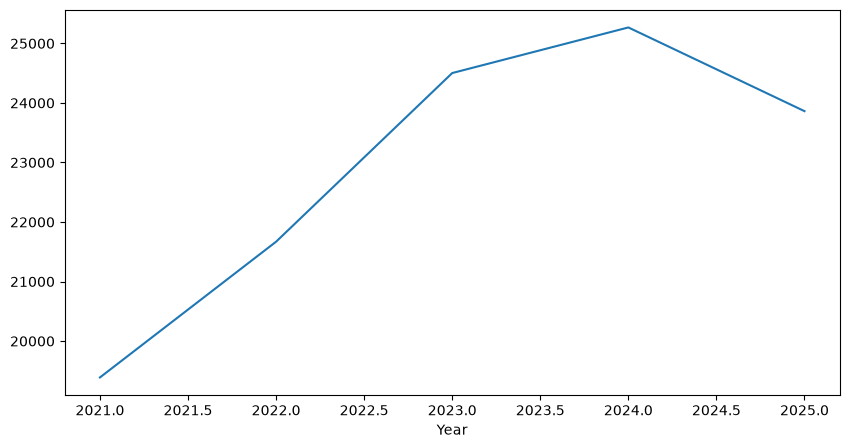

In [73]:
df['Year'].value_counts().sort_index().plot(kind='line', figsize=(10, 5))

## Time of the crime


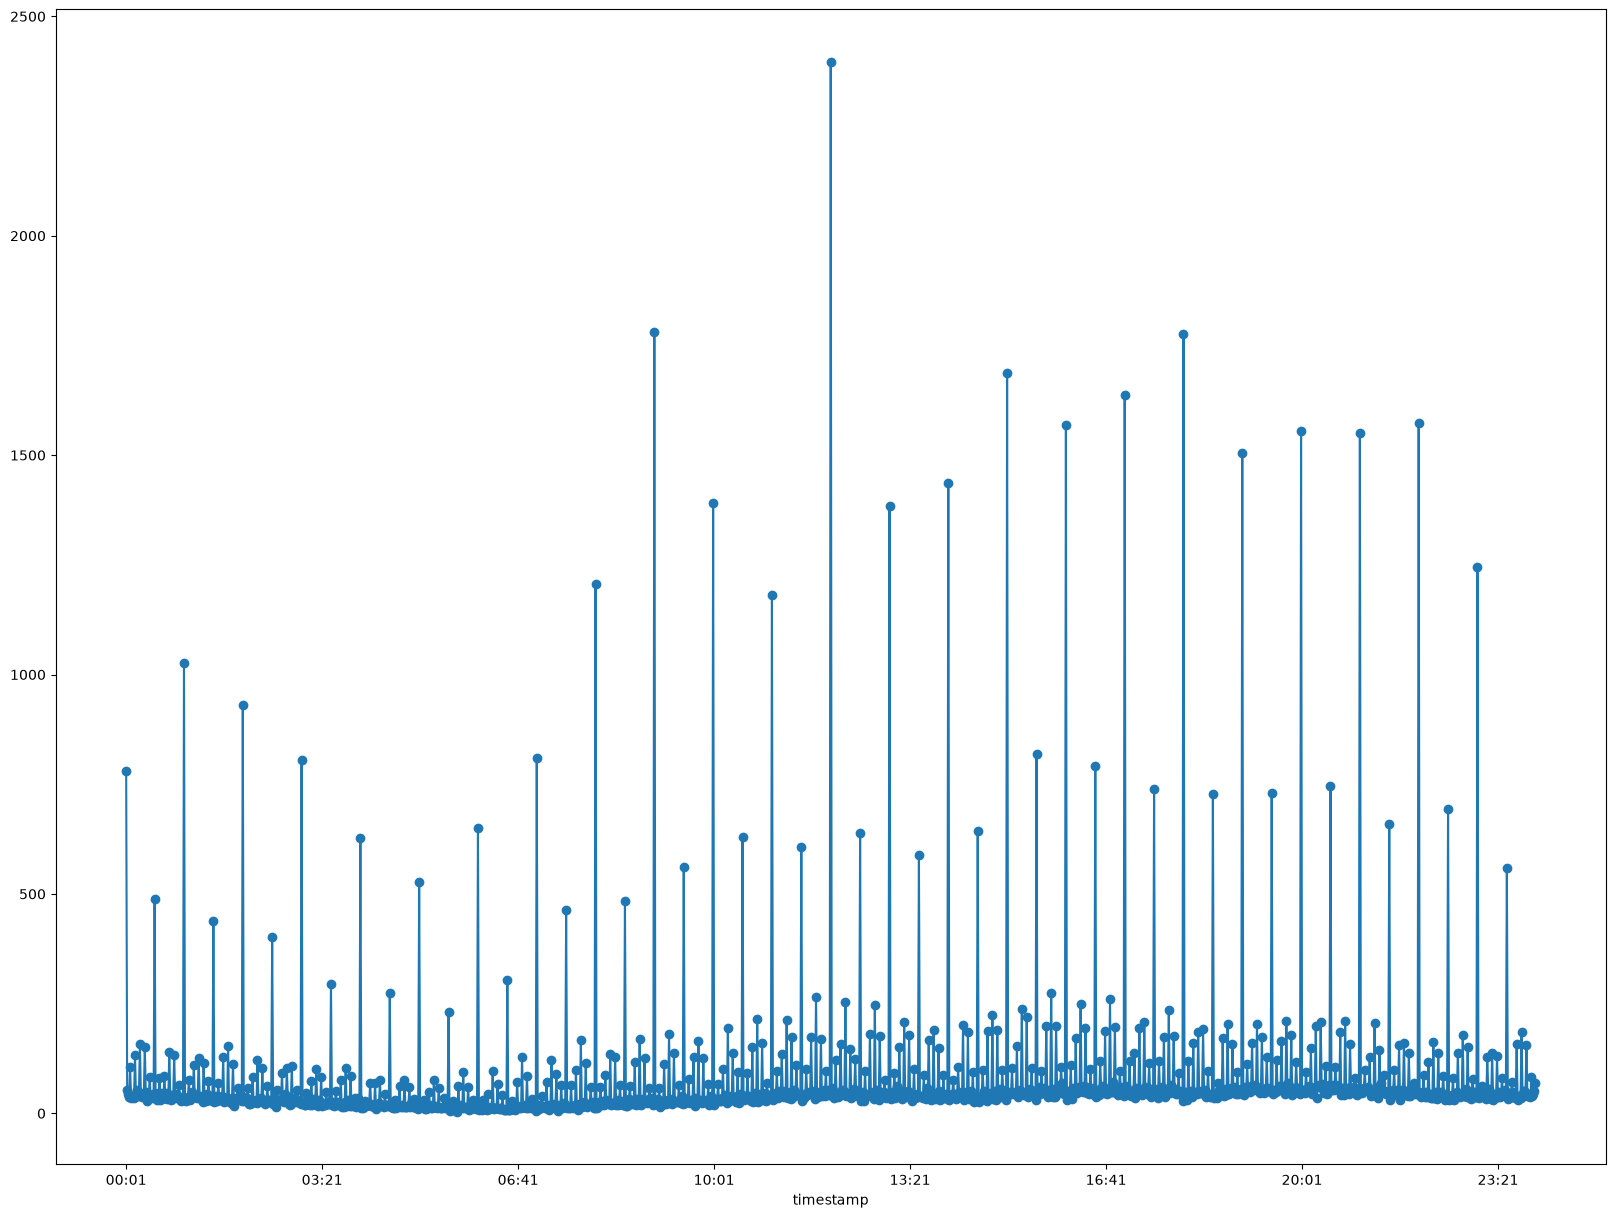

In [84]:
df['timestamp'].value_counts().sort_index().plot(figsize=(20,15))
plt.scatter(x=df['timestamp'].value_counts().sort_index().index, y=df['timestamp'].value_counts().sort_index().values)

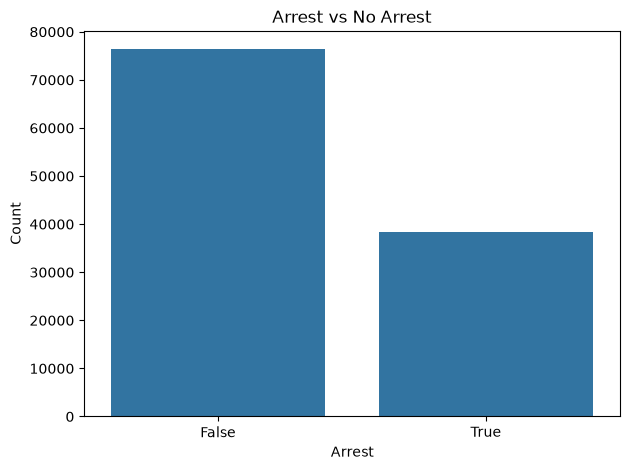

In [85]:
arrest_counts = df["Arrest"].value_counts()

plt.figure()
sns.countplot(data=df, x="Arrest")
plt.title("Arrest vs No Arrest")
plt.xlabel("Arrest")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

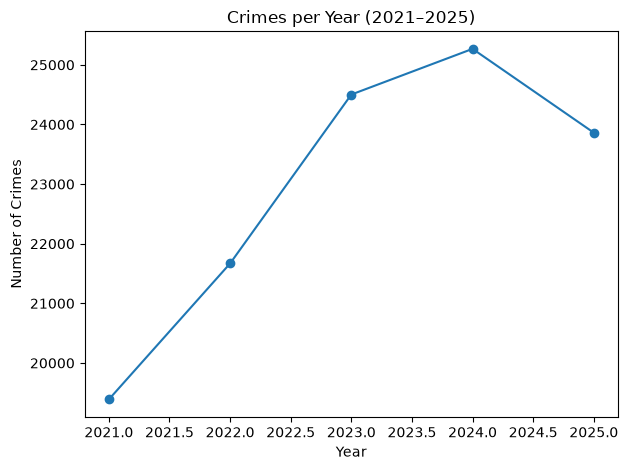

In [87]:
yearly = df.groupby("Year").size()
plt.figure()
yearly.plot(kind="line", marker="o")
plt.title("Crimes per Year (2021–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

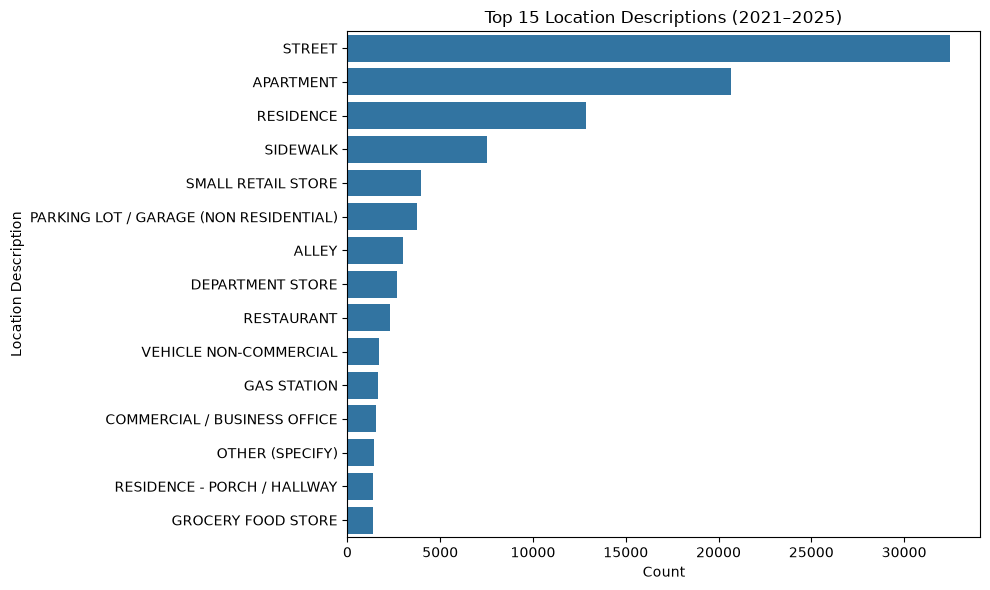

In [89]:
loc_desc_counts = df["Location Description"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=loc_desc_counts.values, y=loc_desc_counts.index)
plt.title("Top 15 Location Descriptions (2021–2025)")
plt.xlabel("Count")
plt.ylabel("Location Description")
plt.tight_layout()
plt.show()

## Bivariate / Multi Variate

In [91]:
top_locs = df["Location Description"].value_counts().head(10).index
top_crimes_loc = df["Primary Type"].value_counts().head(8).index

df_sub = df[
    df["Location Description"].isin(top_locs) &
    df["Primary Type"].isin(top_crimes_loc)
]

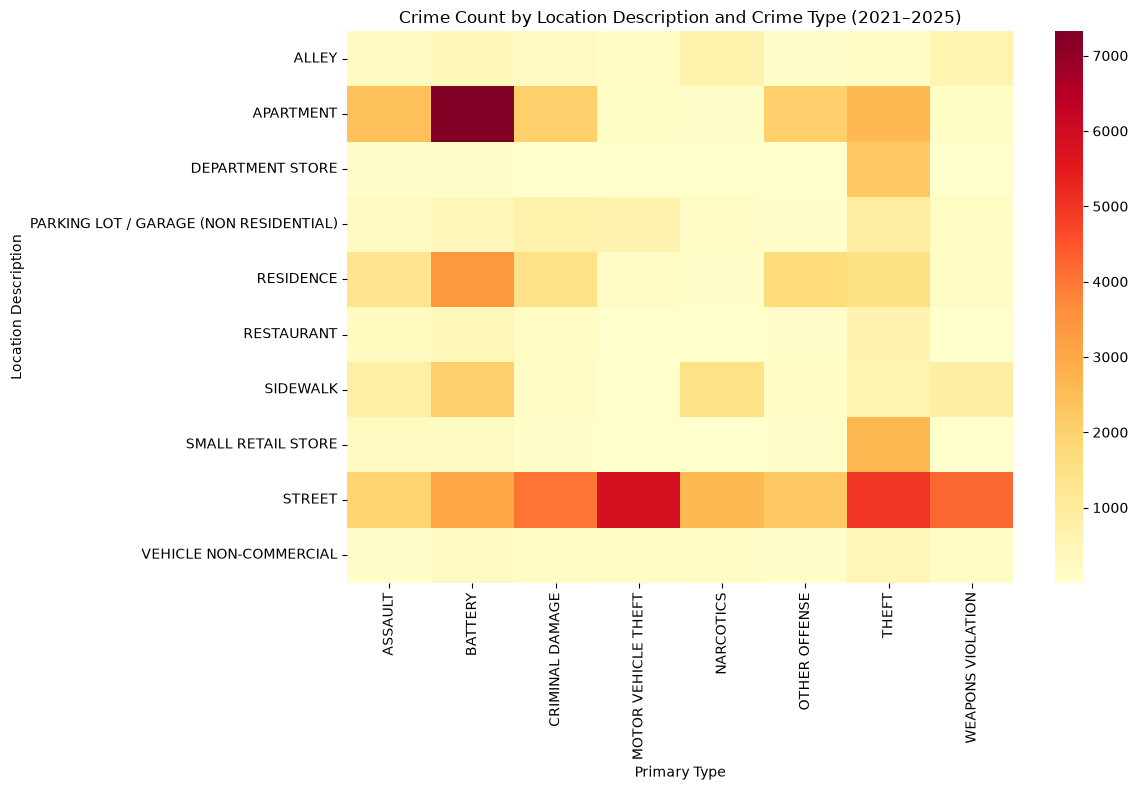

In [92]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    pd.crosstab(df_sub["Location Description"], df_sub["Primary Type"]),
    cmap="YlOrRd"
)
plt.title("Crime Count by Location Description and Crime Type (2021–2025)")
plt.xlabel("Primary Type")
plt.ylabel("Location Description")
plt.tight_layout()
plt.show()

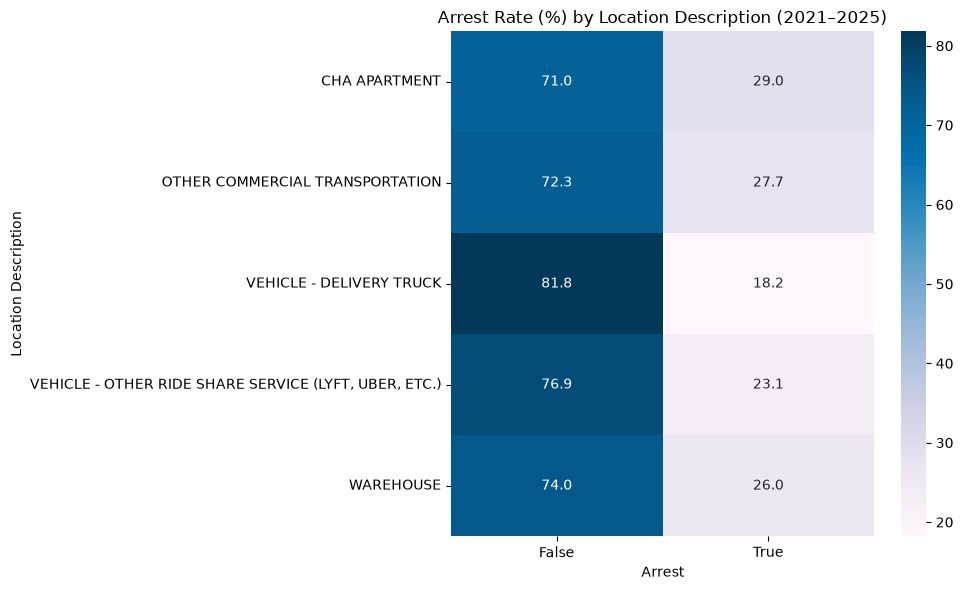

In [93]:
loc_arrest = pd.crosstab(df["Location Description"], df["Arrest"], normalize="index") * 100
loc_arrest_top = loc_arrest.loc[loc_arrest.sum(axis=1) > 100].head(15)

plt.figure(figsize=(10, 6))
sns.heatmap(loc_arrest_top, annot=True, fmt=".1f", cmap="PuBu")
plt.title("Arrest Rate (%) by Location Description (2021–2025)")
plt.xlabel("Arrest")
plt.ylabel("Location Description")
plt.tight_layout()
plt.show()

<Axes: xlabel='Year'>

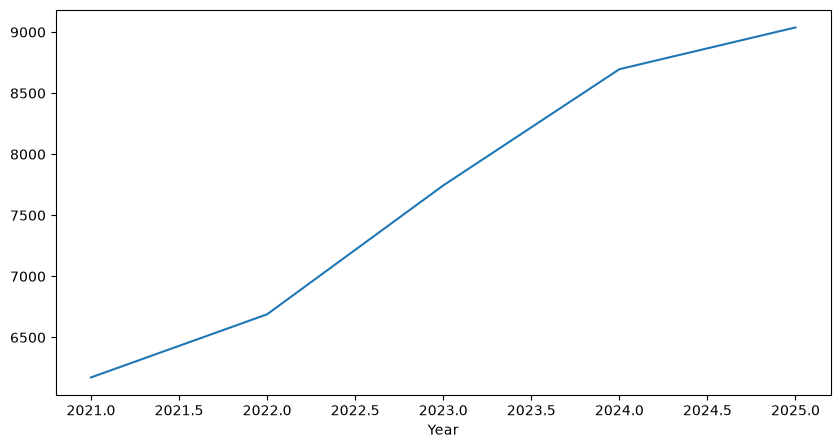

In [97]:
df.loc[df['Arrest'] == True, 'Year'].value_counts().head(10).plot(kind='line', figsize=(10, 5))